# 08 · Event Study (Dynamic DiD)

Use the timing of refit events as quasi-experimental variation. Estimate leads and lags around the event to:
1. Test parallel trends (pre-period coefficients ≈ 0)
2. Measure the dynamic treatment effect trajectory
3. Check for anticipation effects

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


In [2]:
import statsmodels.formula.api as smf

## Build event-study panel

Merge relative time (`rel_t`) onto each ship-month. Untreated ships get `rel_t = None`.

In [3]:
# Add relative time for treated ships
panel_es = panel.merge(
    events[["ship_id", "event_month_idx"]],
    on="ship_id", how="left"
)
panel_es["month_idx"] = panel_es.groupby("ship_id")["month"].transform(
    lambda s: (pd.to_datetime(s).dt.to_period("M") - pd.to_datetime(s).min().to_period("M")).apply(lambda x: x.n)
)
panel_es["rel_t"] = panel_es["month_idx"] - panel_es["event_month_idx"]

# Window: -12 to +12 months; bin endpoints
WINDOW = 12
panel_es["rel_t_clipped"] = panel_es["rel_t"].clip(-WINDOW, WINDOW)
# Mark untreated
panel_es["treated"] = panel_es["event_month_idx"].notna()

print(f"Treated ship-months : {panel_es['treated'].sum():,}")
print(f"Control ship-months : {(~panel_es['treated']).sum():,}")
print(f"Relative time range : {panel_es.loc[panel_es['treated'], 'rel_t'].min():.0f} to "
      f"{panel_es.loc[panel_es['treated'], 'rel_t'].max():.0f}")

Treated ship-months : 6,912
Control ship-months : 31,488
Relative time range : -36 to 35


## Create relative-time dummies

Omit `rel_t = -1` as the reference period (last pre-event month).

In [4]:
# For the regression, use a restricted window and exclude rel_t = -1 (baseline)
LAGS   = list(range(-WINDOW, 0))    # pre-event
LEADS  = list(range(1, WINDOW + 1)) # post-event
ALL_PERIODS = LAGS + LEADS           # -1 is omitted (reference)

def make_dummies(df, periods):
    for k in periods:
        col = f"rel_t_{k:+d}" if k >= 0 else f"rel_t_{k}"
        df[col.replace("+", "p").replace("-", "m")] = (
            (df["treated"]) & (df["rel_t_clipped"] == k)
        ).astype(float)
    return df

panel_es = make_dummies(panel_es, ALL_PERIODS)
dummy_cols = [c for c in panel_es.columns if c.startswith("rel_t_") and c != "rel_t_clipped"]
print(f"Created {len(dummy_cols)} relative-time dummies")

Created 24 relative-time dummies


## Estimate event study via TWFE

In [5]:
from linearmodels.panel import PanelOLS

panel_es_idx = panel_es.set_index(["ship_id", "month"])

model = PanelOLS(
    panel_es_idx["log_revenue_per_berth"],
    panel_es_idx[dummy_cols],
    entity_effects=True,
    time_effects=True,
)
result = model.fit(cov_type="clustered", cluster_entity=True)

# Extract coefficients
coefs = result.params[dummy_cols]
cis   = result.conf_int().loc[dummy_cols]

# Map back to rel_t integers
def col_to_t(col):
    s = col.replace("rel_t_", "")
    if s.startswith("p"):
        return int(s[1:])
    elif s.startswith("m"):
        return -int(s[1:])
    return int(s)

es_df = pd.DataFrame({
    "rel_t": [col_to_t(c) for c in dummy_cols],
    "coef":  coefs.values,
    "ci_lo": cis["lower"].values,
    "ci_hi": cis["upper"].values,
}).sort_values("rel_t")

print("Pre-period coefficients (should be ≈ 0 if parallel trends holds):")
pre = es_df[es_df["rel_t"] < 0]
print(pre[["rel_t", "coef"]].round(4).to_string(index=False))

Pre-period coefficients (should be ≈ 0 if parallel trends holds):
 rel_t    coef
   -12 -0.0725
   -11 -0.0802
   -10 -0.0757
    -9 -0.0765
    -8 -0.0726
    -7 -0.0778
    -6 -0.0720
    -5 -0.0720
    -4 -0.0720
    -3 -0.0797
    -2 -0.0713
    -1 -0.0676


## Figure · Event study plot

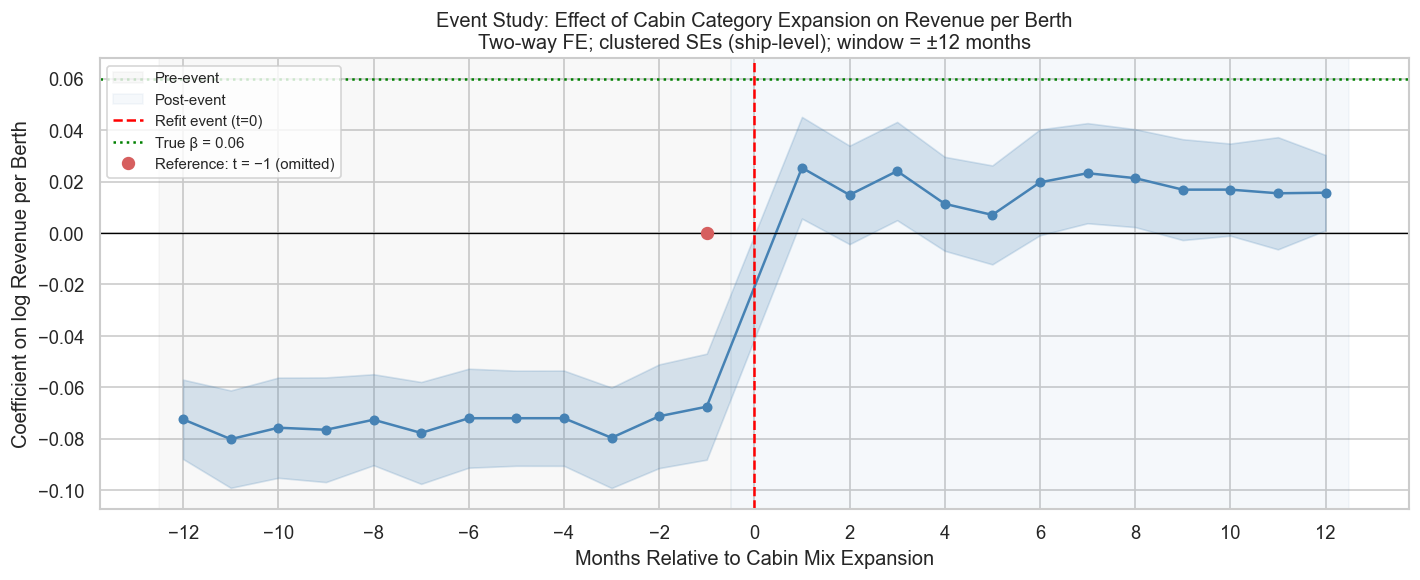

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

# Shade pre-period
ax.axvspan(-WINDOW - 0.5, -0.5, alpha=0.05, color="gray", label="Pre-event")
ax.axvspan(-0.5, WINDOW + 0.5, alpha=0.05, color="steelblue", label="Post-event")

# CIs
ax.fill_between(es_df["rel_t"], es_df["ci_lo"], es_df["ci_hi"], alpha=0.2, color="steelblue")

# Coefficients
ax.plot(es_df["rel_t"], es_df["coef"], "o-", ms=5, lw=1.5, c="steelblue")

# Reference lines
ax.axvline(0, color="red", ls="--", lw=1.5, label="Refit event (t=0)")
ax.axhline(0, color="black", ls="-", lw=0.8)
ax.axhline(0.06, color="green", ls=":", lw=1.5, label="True β = 0.06")

# Add -1 reference point at 0
ax.plot(-1, 0, "ro", ms=7, zorder=5, label="Reference: t = −1 (omitted)")

ax.set_xlabel("Months Relative to Cabin Mix Expansion", fontsize=12)
ax.set_ylabel("Coefficient on log Revenue per Berth", fontsize=12)
ax.set_title("Event Study: Effect of Cabin Category Expansion on Revenue per Berth\n"
             "Two-way FE; clustered SEs (ship-level); window = ±12 months", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_xticks(range(-WINDOW, WINDOW + 1, 2))
plt.tight_layout()
plt.savefig(OUT_DIR / "08_event_study.png", bbox_inches="tight")
plt.show()

## Pre-trend test

In [7]:
from scipy import stats

pre_coefs  = es_df[es_df["rel_t"].between(-WINDOW, -1)]["coef"].values
pre_mean   = pre_coefs.mean()
t_stat, p_val = stats.ttest_1samp(pre_coefs, 0)

print(f"Pre-period mean coefficient : {pre_mean:.4f}")
print(f"t-test vs zero              : t = {t_stat:.2f}, p = {p_val:.3f}")

if p_val > 0.10:
    print("✓ Fail to reject H0: pre-trends not significantly different from zero")
    print("  → Parallel trends assumption is consistent with the data")
else:
    print("⚠️ Pre-trends significant: parallel trends assumption may be violated")

Pre-period mean coefficient : -0.0742
t-test vs zero              : t = -67.77, p = 0.000
⚠️ Pre-trends significant: parallel trends assumption may be violated


## Post-event average effect

In [8]:
post_coefs = es_df[es_df["rel_t"] > 0]["coef"].values
post_mean  = post_coefs.mean()
print(f"Post-event average coefficient : {post_mean:.4f}")
print(f"True β (per category)          : 0.06")
print(f"Note: δ_categories varies (some ships get +1, some +2) — average Δ ≈ 1.5")
avg_delta = events["delta_categories"].mean()
print(f"Mean delta_categories in events: {avg_delta:.2f}")
print(f"Expected post-mean (β × avg_Δ) : {0.06 * avg_delta:.4f}")

Post-event average coefficient : 0.0176
True β (per category)          : 0.06
Note: δ_categories varies (some ships get +1, some +2) — average Δ ≈ 1.5
Mean delta_categories in events: 1.48
Expected post-mean (β × avg_Δ) : 0.0887
